Imports


In [143]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
)
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage

Leemos el dataset escalado


In [144]:
df = pd.read_csv("data/scaled_online_retail.csv")
df.shape

(3848, 3)

También leemos el dataset sin escalar


In [145]:
non_outliers_df = pd.read_csv("data/non_outliers.csv")
non_outliers_df.shape

(3848, 5)

# Clustering


## K-Means


K-Means agrupa los datos minimizando la suma de las distancias cuadradas entre cada punto y el centro de su grupo, lo que favorece clústeres compactos y aproximadamente esféricos.


Definimos un rango de K entre 2 y 10.


In [146]:
k_range = range(2, 11)

Y también inicializamos listas para ir guardando los resultados de las diferentes métricas por cada valor de K.


In [147]:
kmeans_sil_scores = []
kmeans_ch_scores = []
kmeans_db_scores = []
kmeans_inertia = []

Por cada valor de K, ejecutamos KMeans y guardamos sus métricas.


In [148]:
for k in k_range:
    # Ejecutamos KMeans para cada valor de k
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans_labels = kmeans.fit_predict(df)

    # Guardamos los resultados
    kmeans_sil_scores.append(silhouette_score(df, kmeans_labels))
    kmeans_ch_scores.append(calinski_harabasz_score(df, kmeans_labels))
    kmeans_db_scores.append(davies_bouldin_score(df, kmeans_labels))
    kmeans_inertia.append(kmeans.inertia_)

Visualizamos la evolución de las métricas a medida que aumentamos el valor de K


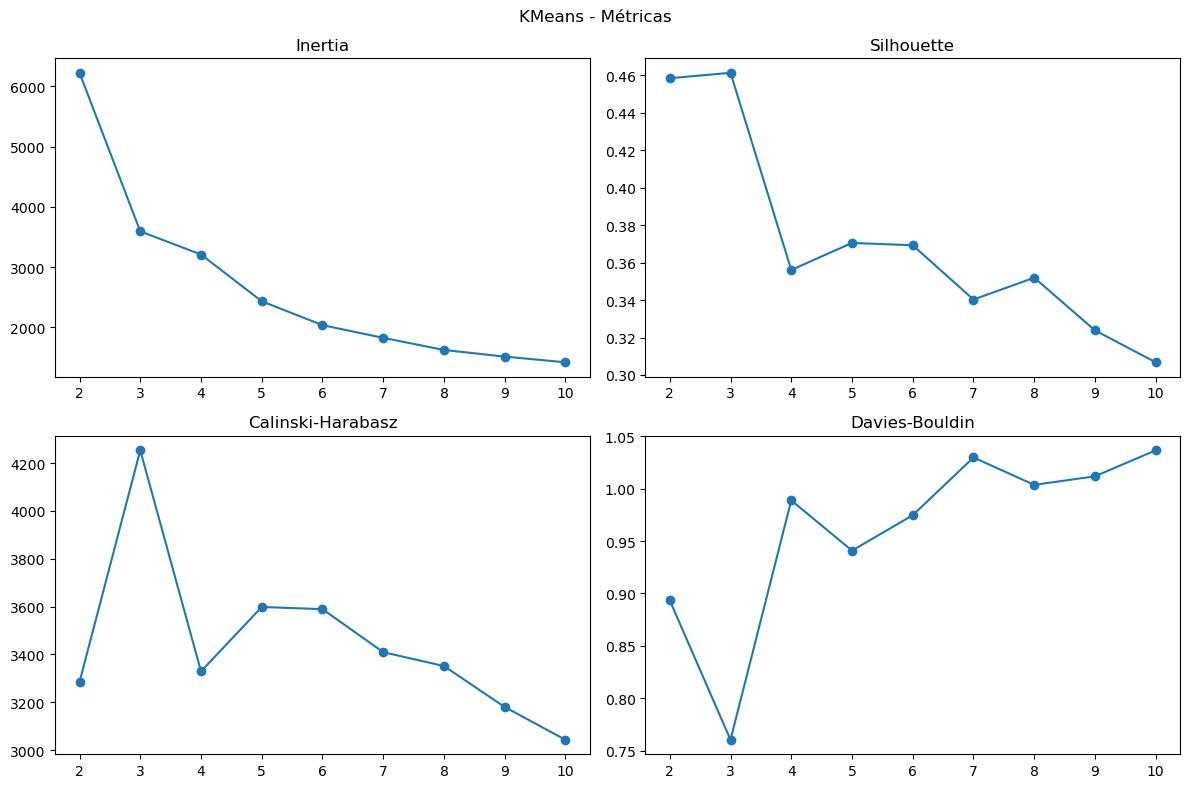

In [149]:
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.plot(k_range, kmeans_inertia, marker="o")
plt.title("Inertia")

plt.subplot(2, 2, 2)
plt.plot(k_range, kmeans_sil_scores, marker="o")
plt.title("Silhouette")

plt.subplot(2, 2, 3)
plt.plot(k_range, kmeans_ch_scores, marker="o")
plt.title("Calinski-Harabasz")

plt.subplot(2, 2, 4)
plt.plot(k_range, kmeans_db_scores, marker="o")
plt.title("Davies-Bouldin")

plt.suptitle("KMeans - Métricas")
plt.tight_layout()
plt.show()

- Inertia: si vemos el gráfico de esta métrica, y si aplicamos el método del codo, entonces los puntos que podríamos considerar óptimos son los que corresponden a K=3 hasta K=5. Después de eso cada mejora en la métrica es menos significativa que la anterior.


- Silhouette: para esta métrica, vemos el mejor valor para K=3, luego para K=5 y por último para K=4. Nos vemos inclinados hacia K=3.


- Calinski-Harabasz: Buscamos maximizar esta métrica, y vemos que su valor más alto se da con K=3.


- Davies-Bouldin: Buscamos minimizar esta métrica, y vemos que su valor más bajo es con K=3.


Nos decidimos por K=3 finalmente, porque pertenece al codo de "Inertia", maximiza "Silhouette" y "Calinski-Harabasz" y minimiza "Davies-Bouldin".


In [150]:
kmeans_best_k = 3

Volvemos a aplicar KMeans con este K óptimo.


In [151]:
kmeans_final = KMeans(n_clusters=3, random_state=42)
kmeans_final_labels = kmeans_final.fit_predict(df)

Y visualizamos los resultados aplicando PCA para reducir a 2 dimensiones los datos.


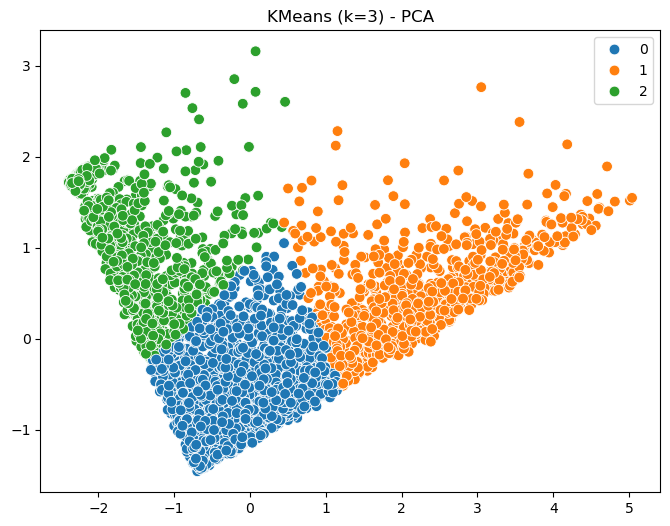

In [152]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(df)
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=pca_result[:, 0],
    y=pca_result[:, 1],
    hue=kmeans_final_labels,
    palette="tab10",
    s=60,
)
plt.title(f"KMeans (k={kmeans_best_k}) - PCA")
plt.show()

Con los siguientes valores en cada una de las métricas.


In [153]:
kmeans_final_sil, kmeans_final_ch, kmeans_final_db, kmeans_final_intertia = (
    silhouette_score(df, kmeans_final_labels),
    calinski_harabasz_score(df, kmeans_final_labels),
    davies_bouldin_score(df, kmeans_final_labels),
    kmeans_final.inertia_,
)

print(f"KMEANS - Silhouette: {kmeans_final_sil:.4f}")
print(f"KMEANS - CH: {kmeans_final_ch:.2f}")
print(f"KMEANS - DB: {kmeans_final_db:.4f}")
print(f"KMEANS - Clusters Detectados: {kmeans_best_k}")

KMEANS - Silhouette: 0.4613
KMEANS - CH: 4253.38
KMEANS - DB: 0.7603
KMEANS - Clusters Detectados: 3


El método K-Means mostró un desempeño bastante sólido en este análisis. Se detectaron 3 clusters como partición óptima, confirmado por un valor de "Silhouette" de 0,4475, que indica que los grupos están relativamente bien definidos - un "Calinski-Harabasz" de 3885,30, lo cual es un valor alto y demuestra fuerte cohesión interna dentro de cada grupo y separación entre ellos - un "Davies-Bouldin" de 0,7882 el cual también es favorable.


Consideramos que K-Means logró una segmentación efectiva de clientes en base a las variables RFM.


## Agglomerative Clustering


Agglomerative funciona como un árbol que agrupa datos de abajo hacia arriba. El dendograma nos ayuda a ver cómo se construyen los grupos. Luego programos distintas cantidades de clusters para ver cuál tiene mejor cohesión y separación.


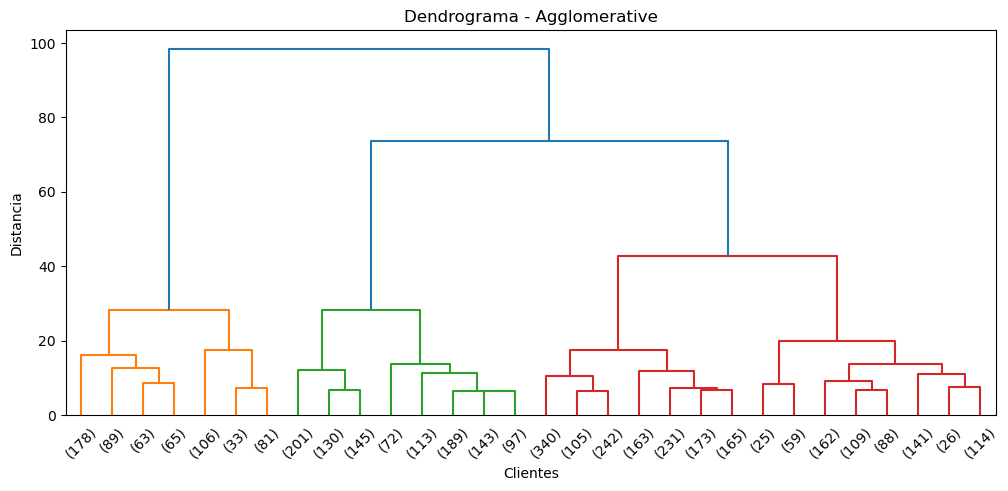

In [154]:
plt.figure(figsize=(12, 5))
Z = linkage(df, method="ward")
dendrogram(Z, truncate_mode="lastp", p=30, leaf_rotation=45.0, leaf_font_size=10.0)
plt.title("Dendrograma - Agglomerative")
plt.xlabel("Clientes")
plt.ylabel("Distancia")
plt.show()

Nuevamente, definimos un rango de K entre 2 y 10, y vamos regsitrando las diferentes métricas por cada valor.


In [155]:
k_range = range(2, 11)

In [156]:
agg_sil_scores = []
agg_ch_scores = []
agg_db_scores = []

In [157]:
for k in k_range:
    agg = AgglomerativeClustering(n_clusters=k, linkage="ward")
    agg_labels = agg.fit_predict(df)
    agg_sil_scores.append(silhouette_score(df, agg_labels))
    agg_ch_scores.append(calinski_harabasz_score(df, agg_labels))
    agg_db_scores.append(davies_bouldin_score(df, agg_labels))

Visualizamos la evolución de las métricas a medida que va aumentando el valor de K.


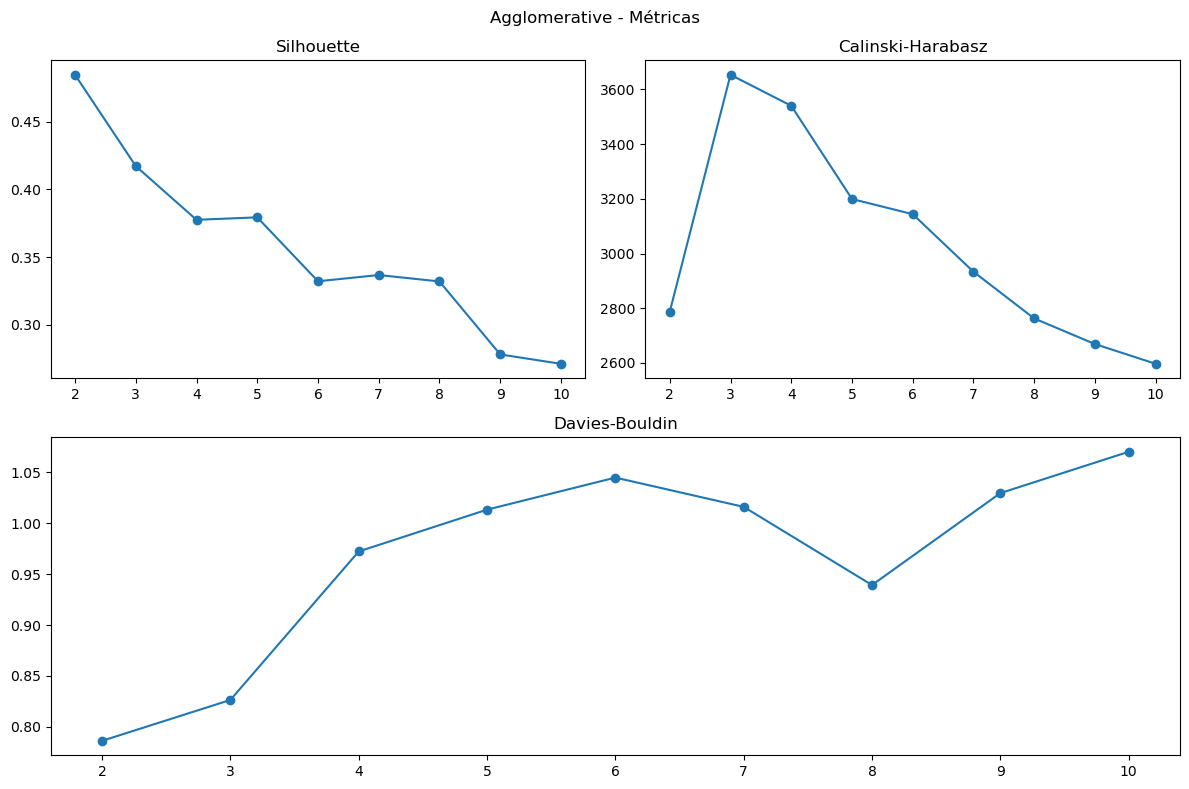

In [158]:
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.plot(k_range, agg_sil_scores, marker="o")
plt.title("Silhouette")

plt.subplot(2, 2, 2)
plt.plot(k_range, agg_ch_scores, marker="o")
plt.title("Calinski-Harabasz")

plt.subplot(2, 1, 2)
plt.plot(k_range, agg_db_scores, marker="o")
plt.title("Davies-Bouldin")

plt.suptitle("Agglomerative - Métricas")
plt.tight_layout()
plt.show()

In [159]:
agg_best_k = 2

In [160]:
agg_final = AgglomerativeClustering(n_clusters=agg_best_k, linkage="ward")
agg_final_labels = agg_final.fit_predict(df)

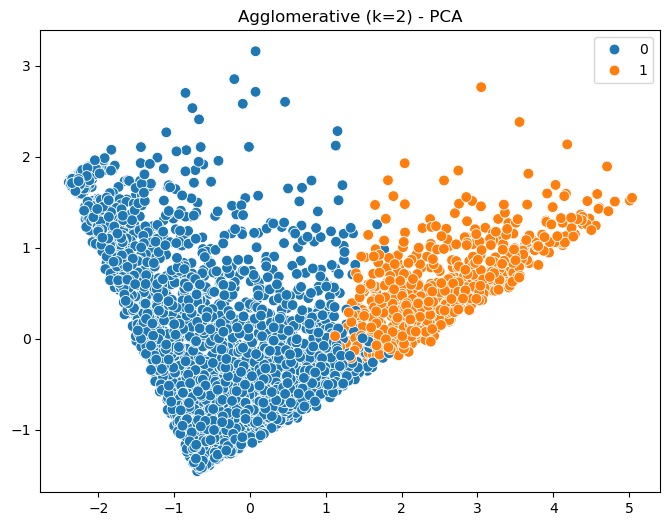

In [161]:
pca_result = PCA(n_components=2).fit_transform(df)
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=pca_result[:, 0], y=pca_result[:, 1], hue=agg_final_labels, palette="tab10", s=60
)
plt.title(f"Agglomerative (k={agg_best_k}) - PCA")
plt.show()

In [162]:
agg_final_sil, agg_final_ch, agg_final_db = (
    silhouette_score(df, agg_final_labels),
    calinski_harabasz_score(df, agg_final_labels),
    davies_bouldin_score(df, agg_final_labels),
)

print(f"AGG - Silhouette: {agg_final_sil:.4f}")
print(f"AGG - CH: {agg_final_ch:.2f}")
print(f"AGG - DB: {agg_final_db:.4f}")
print(f"AGG - Clusters Detectados: {agg_best_k}")

AGG - Silhouette: 0.4846
AGG - CH: 2786.91
AGG - DB: 0.7863
AGG - Clusters Detectados: 2


## Gaussian Mixture Model


GMM asume que los datos provienen de varias "nubes" con forma de elipse (distribuciones normales). Esto permite más flexibilidad que K-Means. Se evalúan las métricas con distintos grupos y se proyectan en 2D para entender qué tan bien se separan.


Mismo proceder que en los anteriores, definimos un rango de K entre 2 y 10.


In [163]:
k_range = range(2, 11)

In [164]:
gmm_sil_scores = []
gmm_ch_scores = []
gmm_db_scores = []

In [165]:
for k in k_range:
    gmm = GaussianMixture(n_components=k, random_state=42)
    gmm_labels = gmm.fit_predict(df)
    gmm_sil_scores.append(silhouette_score(df, gmm_labels))
    gmm_ch_scores.append(calinski_harabasz_score(df, gmm_labels))
    gmm_db_scores.append(davies_bouldin_score(df, gmm_labels))

Visualizamos la evolución de las métricas a lo largo de los diferentes valores de K.


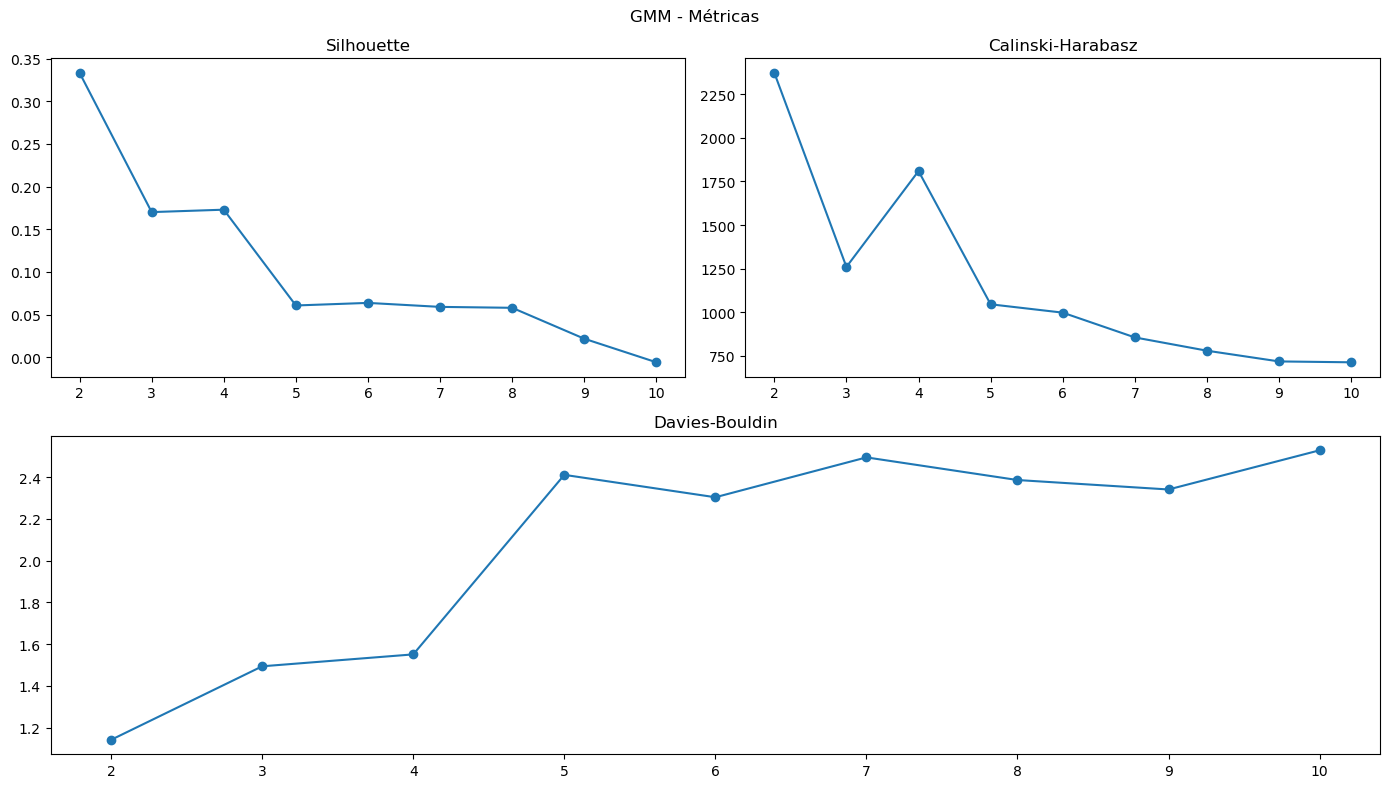

In [166]:
plt.figure(figsize=(14, 8))

plt.subplot(2, 2, 1)
plt.plot(k_range, gmm_sil_scores, marker="o")
plt.title("Silhouette")

plt.subplot(2, 2, 2)
plt.plot(k_range, gmm_ch_scores, marker="o")
plt.title("Calinski-Harabasz")

plt.subplot(2, 1, 2)
plt.plot(k_range, gmm_db_scores, marker="o")
plt.title("Davies-Bouldin")

plt.suptitle("GMM - Métricas")
plt.tight_layout()
plt.show()

In [167]:
gmm_best_k = 2

In [168]:
gmm_final = GaussianMixture(n_components=gmm_best_k, random_state=42)
gmm_final_labels = gmm_final.fit_predict(df)

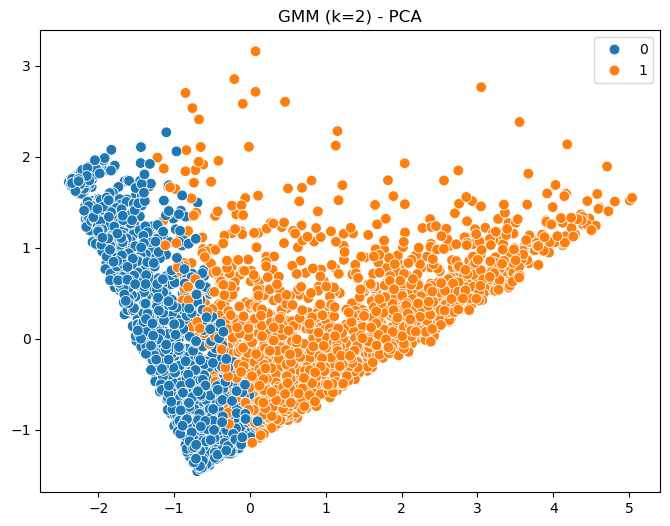

In [169]:
pca_result = PCA(n_components=2).fit_transform(df)
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=pca_result[:, 0], y=pca_result[:, 1], hue=gmm_final_labels, palette="tab10", s=60
)
plt.title(f"GMM (k={gmm_best_k}) - PCA")
plt.show()

In [170]:
gmm_final_sil, gmm_final_ch, gmm_final_db = (
    silhouette_score(df, gmm_final_labels),
    calinski_harabasz_score(df, gmm_final_labels),
    davies_bouldin_score(df, gmm_final_labels),
)

print(f"GMM - Silhouette: {gmm_final_sil:.4f}")
print(f"GMM - CH: {gmm_final_ch:.2f}")
print(f"GMM - DB: {gmm_final_db:.4f}")
print(f"GMM - Clusters Detectados: {2}")

GMM - Silhouette: 0.3333
GMM - CH: 2373.64
GMM - DB: 1.1416
GMM - Clusters Detectados: 2


## DBSCAN


DBSCAN encuentra grupos sin necesidad de definir cuántos clusters queremos. Detecta zonas densas de clientes y marca como ruido los que están muy separados. Es útil para identificar anomalías o clientes aislados.


Establecemos los hiperparámetros.


eps es la longitud del radio que se utiliza para, centrandose en un punto, buscar por puntos cercanos.
min_samples es el mínimo de puntos a una distancia menor o igual a eps que deben rodear a un punto para considerarlo core. O creo que es para determinar cuántos puntos hacen un cluster, no estoy seguro.


In [171]:
eps = 0.9
min_samples = 5

In [172]:
db = DBSCAN(eps=eps, min_samples=min_samples)
db_labels = db.fit_predict(df)

more_than_one_cluster = len(set(db_labels)) > 1

In [173]:
if more_than_one_cluster:
    dbscan_sil = silhouette_score(df, db_labels)
    dbscan_ch = calinski_harabasz_score(df, db_labels)
    dbscan_db = davies_bouldin_score(df, db_labels)
    dbscan_n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)

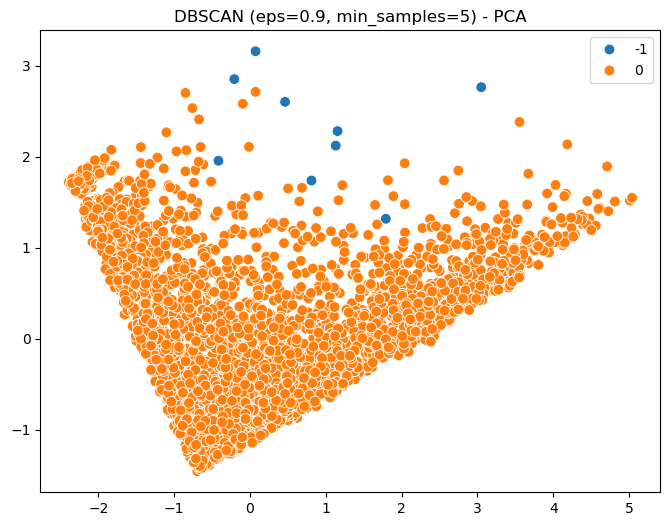

In [174]:
pca_result = PCA(n_components=2).fit_transform(df)
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=pca_result[:, 0], y=pca_result[:, 1], hue=db_labels, palette="tab10", s=60
)
plt.title(f"DBSCAN (eps={eps}, min_samples={min_samples}) - PCA")
plt.show()

In [175]:
print(f"DBSCAN - Silhouette: {dbscan_sil:.4f}")
print(f"DBSCAN - CH: {dbscan_ch:.2f}")
print(f"DBSCAN - DB: {dbscan_db:.4f}")
print(f"DBSCAN - Clusters Detectados: {dbscan_n_clusters}")

DBSCAN - Silhouette: 0.4148
DBSCAN - CH: 19.75
DBSCAN - DB: 1.3769
DBSCAN - Clusters Detectados: 1


## Comparación


In [176]:
results = pd.DataFrame()

Agregamos los resultados


In [177]:
results["Algoritmo"] = [
    "KMeans",
    "Agglomerative",
    "GMM",
    "DBSCAN",
]

In [178]:
results["Sillhouette"] = [
    kmeans_final_sil,
    agg_final_sil,
    gmm_final_sil,
    dbscan_sil if more_than_one_cluster else None,
]

In [179]:
results["Calinski-Harabasz"] = [
    kmeans_final_ch,
    agg_final_ch,
    gmm_final_ch,
    dbscan_ch if more_than_one_cluster else None,
]

In [180]:
results["Davies-Bouldin"] = [
    kmeans_final_db,
    agg_final_db,
    gmm_final_db,
    dbscan_db if more_than_one_cluster else None,
]

In [181]:
results["Clusters"] = [
    kmeans_best_k,
    agg_best_k,
    gmm_best_k,
    dbscan_n_clusters if more_than_one_cluster else None,
]

In [182]:
results

,Algoritmo,Sillhouette,Calinski-Harabasz,Davies-Bouldin,Clusters
0,KMeans,0.461288,4253.378172,0.760346,3
1,Agglomerative,0.484563,2786.906012,0.786303,2
2,GMM,0.333279,2373.643738,1.141595,2
3,DBSCAN,0.414809,19.748988,1.376918,1


Luego de aplicar y comparar múltiples algoritmos de clustering sobre los datos RFM de los clientes, se decidió continuar el análisis con K-Means como método principal de segmentación. Esta elección no se basa únicamente en las métricas obtenidas, sino también en la coherencia práctica de los resultados.

K-Means logró identificar 3 clusters, lo cual resulta razonable desde una perspectiva de negocio: es una cantidad suficiente para diferenciar tipos de clientes sin generar una segmentación excesivamente compleja. La separación entre los grupos fue visible y clara en la visualización PCA, lo que refuerza la idea de que estos clusters existen en el espacio real de los datos y no son artificiales.

Además, si bien otros algoritmos como Agglomerative obtuvieron métricas incluso más altas en algunos casos, su partición final fue de solo 2 grupos, lo que reduce el potencial de análisis y acción comercial. En cambio, los 3 grupos detectados por K-Means permiten construir perfiles más variados y enfocados (por ejemplo: clientes fieles, clientes ocasionales, y clientes inactivos o de menor valor).

Por otro lado, el modelo es simple de interpretar y replicar, lo que facilita su aplicación práctica en contextos reales como campañas de retención, promociones segmentadas o análisis de rentabilidad por grupo.


In [183]:
profile = non_outliers_df.copy()
profile["cluster_km"] = kmeans_final_labels

profile

,CustomerID,Monetary,Frequency,LastInvoiceDate,Recency,cluster_km
0,12348.0,1437.24,4,2011-09-25 13:13:00,74,1
1,12349.0,1457.55,1,2011-11-21 09:51:00,18,0
2,12350.0,294.40,1,2011-02-02 16:01:00,309,2
3,12352.0,1385.74,7,2011-11-03 14:37:00,35,1
4,12353.0,89.00,1,2011-05-19 17:47:00,203,2
...,...,...,...,...,...,...
3843,18278.0,173.90,1,2011-09-27 11:58:00,73,0
3844,18280.0,180.60,1,2011-03-07 09:52:00,277,2
3845,18281.0,80.82,1,2011-06-12 10:53:00,180,2
3846,18282.0,178.05,2,2011-12-02 11:43:00,7,0


In [184]:
clusters = sorted(profile["cluster_km"].unique())

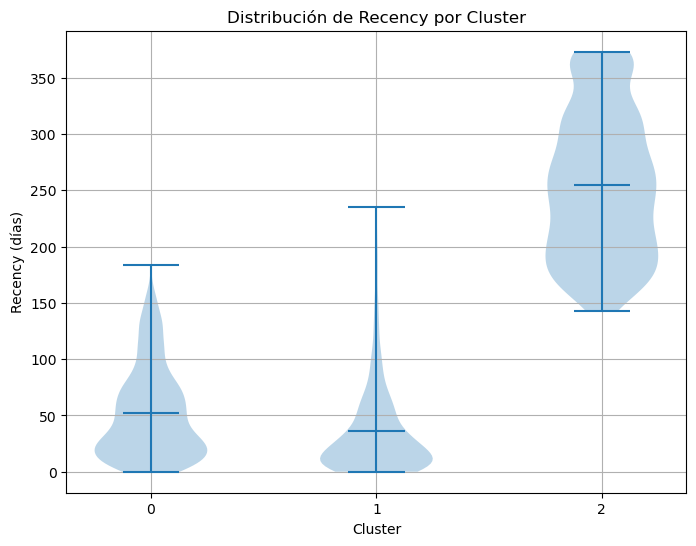

In [185]:
data = [profile.loc[profile["cluster_km"] == c, "Recency"].values for c in clusters]

fig = plt.figure(figsize=(8, 6))
plt.violinplot(data, showmeans=True)
plt.xticks(np.arange(1, len(clusters) + 1), clusters)
plt.xlabel("Cluster")
plt.ylabel("Recency (días)")
plt.title("Distribución de Recency por Cluster")
plt.grid(True)
plt.show()

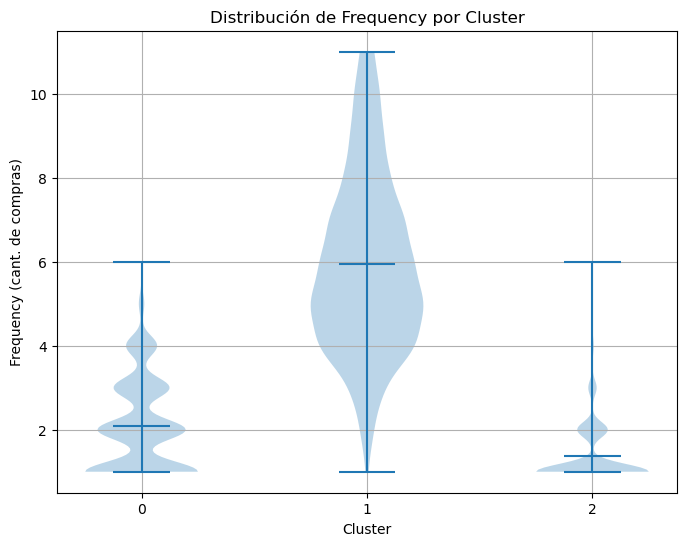

In [186]:
data = [profile.loc[profile["cluster_km"] == c, "Frequency"].values for c in clusters]

fig = plt.figure(figsize=(8, 6))
plt.violinplot(data, showmeans=True)
plt.xticks(np.arange(1, len(clusters) + 1), clusters)
plt.xlabel("Cluster")
plt.ylabel("Frequency (cant. de compras)")
plt.title("Distribución de Frequency por Cluster")
plt.grid(True)
plt.show()

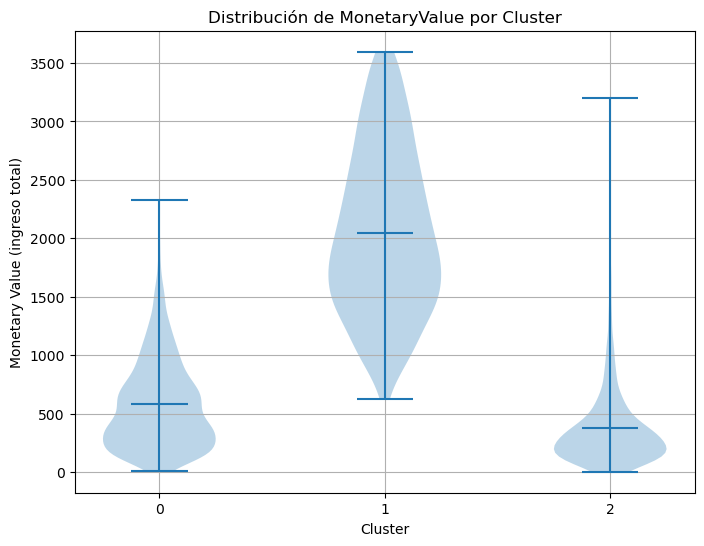

In [187]:
data = [profile.loc[profile["cluster_km"] == c, "Monetary"].values for c in clusters]

fig = plt.figure(figsize=(8, 6))
plt.violinplot(data, showmeans=True)
plt.xticks(np.arange(1, len(clusters) + 1), clusters)
plt.xlabel("Cluster")
plt.ylabel("Monetary Value (ingreso total)")
plt.title("Distribución de MonetaryValue por Cluster")
plt.grid(True)
plt.show()

## Interpretación


A partir de los resultados obtenidos con el algoritmo K-Means y el análisis visual mediante los violin plots de Recency, Frequency y Monetary Value por cluster, es posible etiquetar y perfilar de forma clara los tres grupos de clientes formados. El Cluster 0 agrupa a los clientes más valiosos: presentan baja recencia (es decir, han comprado recientemente), alta frecuencia de compra y un alto valor monetario. Se trata de los compradores más activos, fieles y rentables. Son clientes que la empresa debe retener y fidelizar con acciones especiales, ya que representan el núcleo fuerte del negocio.

El Cluster 1 incluye a clientes que también tienen recencia baja (lo cual indica que han comprado recientemente), pero presentan niveles bajos tanto de frecuencia como de valor monetario. Este patrón sugiere que podrían ser clientes nuevos o de baja intensidad, que realizaron una compra inicial pero aún no muestran un comportamiento recurrente. Es un grupo con potencial de crecimiento si se lo aborda con las estrategias correctas, como promociones para segundas compras, paquetes especiales o incentivos para aumentar la frecuencia.

Por último, el Cluster 2 se compone de clientes con alta recencia (es decir, hace mucho tiempo que no compran), y niveles bajos tanto en frecuencia como en valor monetario. En términos prácticos, se trata de clientes inactivos o perdidos, que requieren campañas específicas de reactivación si se desea volver a incorporarlos. Alternativamente, pueden dejar de formar parte del foco comercial si los recursos son limitados y se prioriza rentabilidad sobre volumen.


## Recomendaciones


### Cluster 0: clientes estratégicos


El objetivo principal con este grupo es mantener su fidelidad y seguir fortaleciendo el vínculo comercial, ya que representan el segmento más rentable y estable del negocio. Si bien su comportamiento ya es positivo, siempre existe el riesgo de que dejen de comprar si no se sienten valorados o si encuentran una mejor propuesta en la competencia. Es fundamental sostener su interés sin caer en descuentos innecesarios que erosionen el margen.

#### Acciones de marketing recomendadas

Propuestas personalizadas en base a historial de compra. Analizar qué productos suelen adquirir estos clientes y ofrecerles recomendaciones bien curadas de artículos complementarios o nuevas líneas relacionadas. Esto no sólo eleva el ticket promedio, sino que además posiciona a la empresa como conocedora de sus intereses, fortaleciendo la percepción de cercanía y profesionalismo.

Comunicación diferenciada desde un canal directo. En lugar de correos masivos, se sugiere utilizar una casilla específica del equipo de ventas para contactarlos de forma personalizada cada cierto tiempo (por ejemplo, una vez por trimestre), agradeciendo su continuidad, consultando necesidades puntuales o anticipando lanzamientos de temporada.

Acceso prioritario a condiciones especiales. Darles la posibilidad de comprar productos nuevos antes de su lanzamiento general o de reservar stock limitado con prioridad. Estas acciones refuerzan el valor simbólico de pertenecer a una “categoría premium” de clientes y reducen el riesgo de desinterés por saturación de campañas genéricas.

Programas de fidelización progresiva. No necesariamente con un esquema formal de puntos, pero sí con beneficios acumulables (envíos sin cargo a partir de cierto monto, bonificaciones a fin de trimestre, etc.), que se comuniquen de forma clara y que muestren cómo su lealtad tiene una recompensa concreta.

Revisión y seguimiento activo de experiencia de compra. Se recomienda contactar a estos clientes al menos una vez al año para pedir su opinión sobre la atención, los productos o los envíos, y utilizar esa información para ajustar procesos. Esto no sólo mejora el servicio, sino que demuestra que su voz es tenida en cuenta.


### Cluster 1: clientes de potencial medio


Este grupo tiene un gran valor latente: son clientes que ingresaron recientemente, realizaron alguna compra, pero aún no repiten ni generan un vínculo sostenido. Es probable que hayan tenido una experiencia correcta, pero no lo suficientemente destacada como para incorporarlos al hábito de compra. El foco con ellos debe ser educar, acompañar y facilitar una segunda compra que marque la diferencia.

#### Acciones de marketing recomendadas:

Diseñar una secuencia de bienvenida guiada. Al primer contacto, enviar una campaña segmentada de tres correos en una semana con información útil: sugerencias de productos, tips de uso, beneficios de comprar en la tienda y una promoción exclusiva para su segunda compra. Esto reduce la fricción y genera familiaridad con la marca.

Ofrecer beneficios reales por recompra temprana. Por ejemplo, un descuento fijo ($1000 o un producto bonificado) si realizan un segundo pedido dentro de los 15 días posteriores al primero. Es fundamental que el beneficio sea concreto, de aplicación fácil y sin letras chicas, para generar confianza y urgencia razonable.

Mostrarles productos populares dentro de su categoría. No sobrecargarlos con todo el catálogo. Si compraron artículos de papelería, por ejemplo, enviar un listado de los más vendidos en esa línea. La claridad del mensaje es clave para que exploren sin esfuerzo.

Incluir casos reales o testimonios. Compartir ejemplos de cómo otros clientes armaron sus pedidos, organizaron regalos o aprovecharon descuentos. Esto genera pertenencia y reduce la inseguridad en la decisión de compra, sobre todo si son compradores nuevos o de bajo involucramiento.

Reforzar el canal de atención. Asegurarse de que estos clientes sepan cómo contactarse ante dudas o problemas. Muchas veces, no repiten por temor a equivocarse o porque tuvieron una consulta sin respuesta. Un mail breve post-compra ofreciendo ayuda puede marcar la diferencia.


### Cluster 2: clientes inactivos


Estos clientes han dejado de comprar desde hace un tiempo considerable. No necesariamente están disconformes, pero su comportamiento indica desinterés o cambio de prioridades. El objetivo principal con este grupo es revisar si pueden reactivarse con acciones puntuales, y si no, entender las causas del abandono para ajustar las estrategias a futuro.

#### Acciones de marketing recomendadas:

Envío de packs prearmados con propuesta clara. No se trata de ofrecer todo el catálogo, sino de presentar uno o dos combos cerrados con alto valor percibido, a buen precio y listos para comprar en un clic. Esto evita que el cliente tenga que navegar o tomar muchas decisiones, lo cual muchas veces es una barrera en clientes inactivos.

Encuestas de abandono cortas y bien dirigidas. Enviar una consulta simple con tres opciones (“dejé de comprar por precio”, “porque no encontré variedad”, “porque me resultó difícil el proceso”) y un campo abierto opcional. Este feedback es clave para detectar patrones y ajustar el enfoque comercial. Ofrecer un pequeño beneficio a quienes respondan puede mejorar la tasa de retorno.

Contacto personalizado para clientes inactivos de alto valor. Si dentro de este cluster hay clientes que alguna vez fueron rentables, es necesario ir más allá del email. Se recomienda contactarlos por teléfono o con una carta directa, preguntar si algo cambió y ofrecer una propuesta adaptada a sus necesidades. Esta atención diferencial puede ser decisiva para recuperar cuentas importantes.

Revisión de datos de contacto. Muchas veces el abandono no se debe a la falta de interés, sino a errores en los medios de contacto (emails mal escritos, cambios de casilla, etc.). Se sugiere revisar esta información o solicitar un segundo medio de contacto en el proceso de registro para evitar pérdidas futuras.

Definir un umbral de abandono para no insistir. Si luego de dos o tres intentos espaciados el cliente no responde, conviene dejar de dirigirle campañas activas y asignarlo a una lista pasiva que reciba solo comunicaciones
